In [1]:
import opsimsummaryv2 as opsim
import numpy as np

In [2]:
OpSimSurv = opsim.OpSimSurvey("/fred/oz016/bgao_kn/data/rubin_sim/baseline/baseline_v5.0.1_10yrs.db")

Reading from database sqlite:////fred/oz016/bgao_kn/data/rubin_sim/baseline/baseline_v5.0.1_10yrs.db


Read N = 2092088 observations in 19.66 seconds.
No host file.


Finished compute healpy representation, total number of fields : 390076.


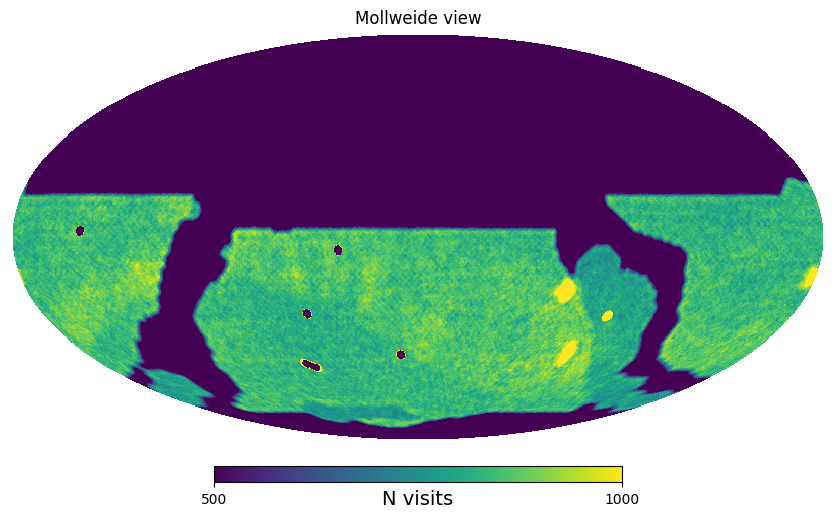

In [3]:
# Compute the healpy representation of the survey
# with a cut to a minimum of 500 and a maximum of 10000 visits
OpSimSurv.compute_hp_rep(nside=256, minVisits=500, maxVisits=10000)

# Plot the healpy configuration
fig = OpSimSurv.plot_hp_rep(min=500, max=1000)

In [5]:
# Get the observations at a given RA, Dec
ra = np.array([197.45033])
dec = np.array([-23.38147])
redshift = np.array([0.01])  # Approximate redshift of GW170817
Obs = OpSimSurv.get_obs_from_coords(ra, dec, is_deg=True)
Obs = list(Obs)
Obs

[                  fieldRA   fieldDec  observationStartMJD  flush_by_mjd  \
 observationId                                                             
 707976         195.797009 -24.250000         62204.341486  62204.403327   
 1801481        195.777707 -24.159162         64144.036704  64144.088022   
 708028         195.797009 -24.250000         62204.365497  62204.403327   
 1801533        195.777707 -24.159162         64144.060348  64144.088022   
 1755186        196.042083 -24.443792         64059.296403  64059.341626   
 ...                   ...        ...                  ...           ...   
 1295906        199.347825 -23.428431         63255.313736  63255.362091   
 254793         199.291473 -23.721395         61454.222863  61454.277482   
 1334092        198.994797 -22.888599         63305.328494      0.000000   
 778942         199.179553 -22.865154         62338.001227  62338.047671   
 778994         199.179553 -22.865154         62338.024936  62338.047671   
 
          

In [6]:
OpSimSurv.sample_coordinates(ra, dec, redshift, nsides=256, is_deg=True)
# Writing simlib
sim = opsim.sim_io.SNANA_Simlib(OpSimSurv, out_path='/fred/oz016/bgao_kn/data/GW170817A', file_suffix="_GW170817A")
sim.write_SIMLIB()

Writing SIMLIB in /fred/oz016/bgao_kn/data/GW170817A/baseline_v5.0.1_10yrs_GW170817A.SIMLIB
SIMLIB wrote in 0.02 sec.



In [4]:
# Sample the survey
N_fields = 50000
seed = 1234

# Sample the suvey with 100 fields
OpSimSurv.sample_survey(N_fields, random_seed=seed)

In [5]:
# Writing simlib
sim = opsim.sim_io.SNANA_Simlib(OpSimSurv, out_path='/fred/oz016/bgao_kn/data/simlib/')
sim.write_SIMLIB()

Writing SIMLIB in /fred/oz016/bgao_kn/data/simlib/baseline_v5.0.1_10yrs.SIMLIB
SIMLIB wrote in 336.89 sec.



In [8]:
sim = opsim.sim_io.SNSIM_obsfile(OpSimSurv, out_path='/fred/oz016/bgao_kn/data/snsim_obsfiles/')
sim.write_survey_file()

Writing obs file in /fred/oz016/bgao_kn/data/snsim_obsfiles/baseline_v5.0.1_10yrs.parquet
Observations file wrote in 1.85 sec.

Writing survey conf yaml file in /fred/oz016/bgao_kn/data/snsim_obsfiles/survey_conf.yaml

Writing LSST field map file in /fred/oz016/bgao_kn/data/snsim_obsfiles/LSST_field_map.dat
